# 05 · Cohort retention

Do customers come back? Cohort = month of a customer's first delivered
order; period = months since that cohort month. Uses `customer_unique_id`.

In [1]:
import json
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path("..").resolve()
PROCESSED = ROOT / "data" / "processed"
RESULTS = ROOT / "results"

In [2]:
orders = pd.read_parquet(PROCESSED / "orders_clean.parquet")
base = orders[orders["order_status"] == "delivered"].copy()
base["order_purchase_timestamp"] = pd.to_datetime(base["order_purchase_timestamp"])
base["order_month"] = base["order_purchase_timestamp"].dt.to_period("M")

first_purchase = base.groupby("customer_unique_id")["order_month"].min().rename("cohort_month")
base = base.merge(first_purchase, on="customer_unique_id")

base["period_number"] = (
    (base["order_month"].dt.year - base["cohort_month"].dt.year) * 12
    + (base["order_month"].dt.month - base["cohort_month"].dt.month)
)

cohort_counts = (
    base.groupby(["cohort_month", "period_number"])["customer_unique_id"]
    .nunique()
    .reset_index()
)
cohort_pivot = cohort_counts.pivot(
    index="cohort_month", columns="period_number", values="customer_unique_id"
)
cohort_sizes = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_sizes, axis=0) * 100

cohort_pivot.to_csv(RESULTS / "cohort_counts.csv")
retention.to_csv(RESULTS / "cohort_retention_pct.csv")

print("Cohort sizes (month 0 = first-purchase month):")
print(cohort_sizes.to_string())

Cohort sizes (month 0 = first-purchase month):
cohort_month
2016-09       1.0
2016-10     262.0
2016-12       1.0
2017-01     717.0
2017-02    1628.0
2017-03    2503.0
2017-04    2256.0
2017-05    3451.0
2017-06    3037.0
2017-07    3752.0
2017-08    4057.0
2017-09    4004.0
2017-10    4328.0
2017-11    7060.0
2017-12    5338.0
2018-01    6842.0
2018-02    6288.0
2018-03    6774.0
2018-04    6582.0
2018-05    6506.0
2018-06    5878.0
2018-07    5949.0
2018-08    6144.0
Freq: M


In [3]:
total_customers = base["customer_unique_id"].nunique()
repeat_customers = base.groupby("customer_unique_id")["order_id"].nunique()
n_repeat = (repeat_customers > 1).sum()
overall_repeat_rate = n_repeat / total_customers * 100

# Month-1 retention weighted by cohort size (a simple mean of per-cohort
# percentages is distorted by the 1-customer launch-month cohorts).
# Excludes cohorts under 50 customers and the incomplete latest cohort.
valid_cohorts = cohort_sizes[cohort_sizes >= 50].index[:-1]
period1_counts = cohort_pivot.loc[valid_cohorts, 1] if 1 in cohort_pivot.columns else None
period0_counts = cohort_sizes.loc[valid_cohorts]
avg_month1_retention = (
    period1_counts.sum() / period0_counts.sum() * 100
    if period1_counts is not None else None
)

print(f"Overall repeat-purchase rate: {overall_repeat_rate:.2f}% "
      f"({n_repeat:,} of {total_customers:,} customers)")
if avg_month1_retention is not None:
    print(f"Month-1 retention (weighted across cohorts, n>=50): {avg_month1_retention:.2f}%")

Overall repeat-purchase rate: 3.00% (2,801 of 93,358 customers)
Month-1 retention (weighted across cohorts, n>=50): 0.48%


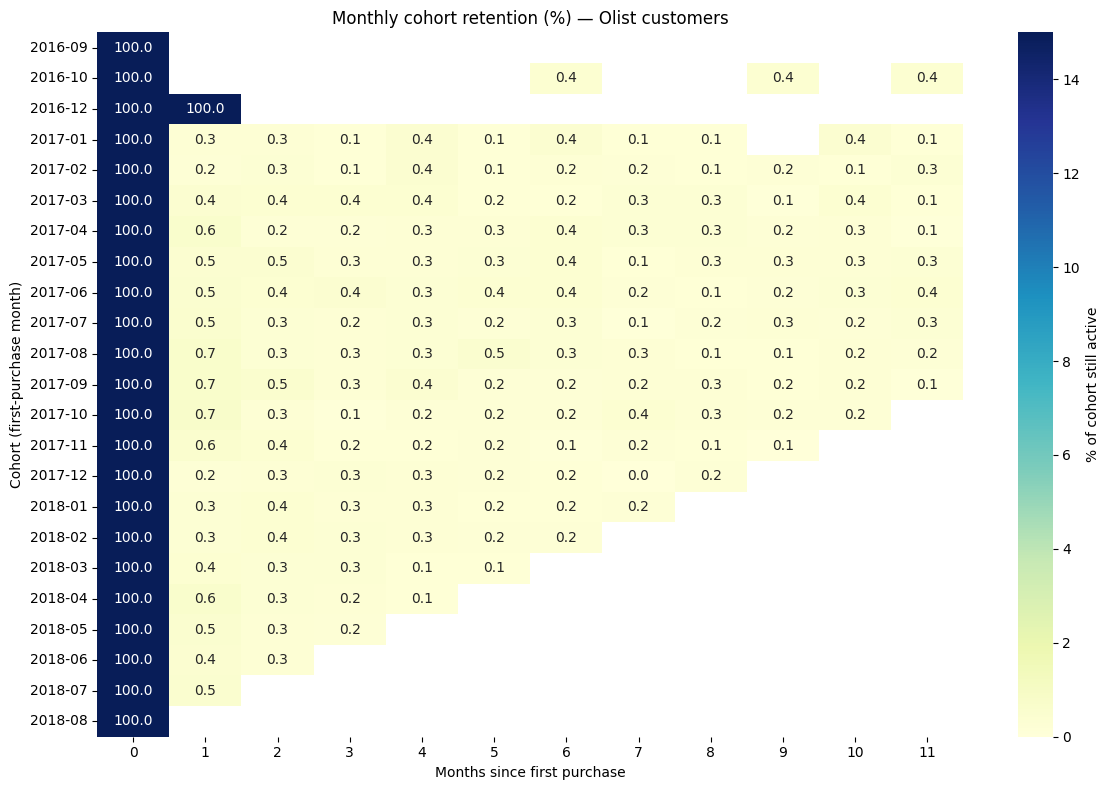

In [4]:
max_period = min(11, retention.columns.max())
plot_data = retention.loc[:, 0:max_period]
plt.figure(figsize=(12, 8))
sns.heatmap(
    plot_data, annot=True, fmt=".1f", cmap="YlGnBu", vmin=0, vmax=15,
    cbar_kws={"label": "% of cohort still active"},
)
plt.title("Monthly cohort retention (%) — Olist customers")
plt.xlabel("Months since first purchase")
plt.ylabel("Cohort (first-purchase month)")
plt.tight_layout()
plt.show()

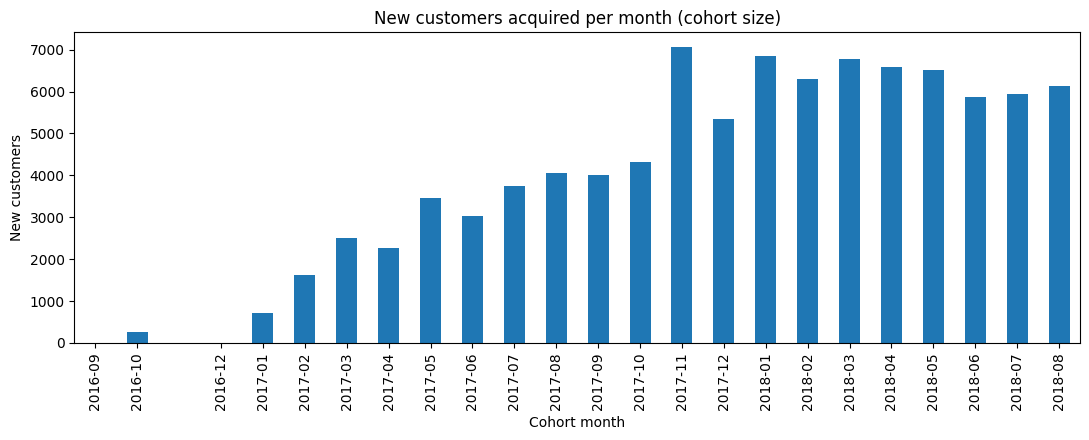

In [5]:
plt.figure(figsize=(11, 4.5))
cohort_sizes.plot(kind="bar")
plt.title("New customers acquired per month (cohort size)")
plt.xlabel("Cohort month")
plt.ylabel("New customers")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [6]:
summary = {
    "total_customers_with_delivered_order": int(total_customers),
    "customers_with_2plus_orders": int(n_repeat),
    "overall_repeat_purchase_rate_pct": round(overall_repeat_rate, 2),
    "month1_retention_pct_weighted": (
        round(float(avg_month1_retention), 2) if avg_month1_retention is not None else None
    ),
    "n_cohort_months": int(len(cohort_sizes)),
}
with open(RESULTS / "cohort_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved: results/cohort_retention_pct.csv, results/cohort_counts.csv, results/cohort_summary.json")

Saved: results/cohort_retention_pct.csv, results/cohort_counts.csv, results/cohort_summary.json
